In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
conn = sqlite3.connect("seguranca.db")

query = """
SELECT 
    id,
    colaborador_id,
    nome_colaborador,
    tag_rfid,
    timestamp,
    tipo_evento
FROM logs_acesso
"""

df = pd.read_sql_query(query, conn)

conn.close()

In [3]:
df.head()

,id,colaborador_id,nome_colaborador,tag_rfid,timestamp,tipo_evento
0,1,NaN,NaN,426096719348,2026-05-13 20:26:40,TAG_DESCONHECIDA
1,2,1.0,Juliana Castanho Teixeira,426096719348,2026-05-13 20:27:21,ENTRADA
2,3,1.0,Juliana Castanho Teixeira,426096719348,2026-05-13 20:27:42,SAIDA
3,4,NaN,NaN,908262641942,2026-05-13 20:27:52,TAG_DESCONHECIDA
4,5,NaN,NaN,908262641942,2026-05-13 20:28:23,TENTATIVA_NEGADA


In [4]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["data"] = df["timestamp"].dt.date

In [5]:
entradas = df[df["tipo_evento"] == "Entrada"]
saidas = df[df["tipo_evento"] == "Saída"]
negados = df[df["tipo_evento"] == "Tentativa Negada"]
invasoes = df[df["tipo_evento"] == "Tag Não Reconhecida"]

In [6]:
print("Entradas:", len(entradas))
print("Saídas:", len(saidas))
print("Negados:", len(negados))
print("Invasões:", len(invasoes))

Entradas: 0
Saídas: 0
Negados: 0
Invasões: 0


In [7]:
negados["nome_colaborador"].value_counts()

Series([], Name: count, dtype: int64)

In [8]:
movimentacoes = df[
    (df["tipo_evento"] == "Entrada") |
    (df["tipo_evento"] == "Saída")
]

usuarios = movimentacoes["nome_colaborador"].unique()

resultado_tempos = []

for usuario in usuarios:

    dados_usuario = movimentacoes[
        movimentacoes["nome_colaborador"] == usuario
    ]

    entradas_usuario = dados_usuario[
        dados_usuario["tipo_evento"] == "Entrada"
    ]["timestamp"].reset_index(drop=True)

    saidas_usuario = dados_usuario[
        dados_usuario["tipo_evento"] == "Saída"
    ]["timestamp"].reset_index(drop=True)

    quantidade = min(len(entradas_usuario), len(saidas_usuario))

    tempo_total = pd.Timedelta(0)

    for i in range(quantidade):
        tempo_total += (saidas_usuario[i] - entradas_usuario[i])

    resultado_tempos.append({
        "usuario": usuario,
        "tempo_total": tempo_total
    })

df_tempo = pd.DataFrame(resultado_tempos)
df_tempo

""


In [9]:
df_tempo["minutos"] = df_tempo["tempo_total"].dt.total_seconds() / 60
df_tempo

KeyError: 'tempo_total'

In [10]:
status = entradas["nome_colaborador"].value_counts().subtract(
    saidas["nome_colaborador"].value_counts(),
    fill_value=0
)

status[status > 0]

Series([], Name: count, dtype: int64)

In [11]:
eventos = df["tipo_evento"].value_counts()
eventos

tipo_evento
TAG_DESCONHECIDA    2
ENTRADA             2
SAIDA               2
TENTATIVA_NEGADA    2
Name: count, dtype: int64

In [12]:
top5 = df_tempo.sort_values("minutos", ascending=False).head(5)

fig, axs = plt.subplots(3, 1, figsize=(10, 14))

# =========================
# Gráfico 1 - Tempo na sala
# =========================

df_tempo.plot(
    x="usuario",
    y="minutos",
    kind="bar",
    legend=False,
    ax=axs[0]
)

axs[0].set_title("Tempo de Permanência na Sala")
axs[0].set_xlabel("Usuário")
axs[0].set_ylabel("Minutos")

# =========================
# Gráfico 2 - Eventos
# =========================

eventos.plot(
    kind="bar",
    ax=axs[1]
)

axs[1].set_title("Eventos do Sistema")
axs[1].set_xlabel("Tipo de Evento")
axs[1].set_ylabel("Quantidade")

# =========================
# Gráfico 3 - TOP 5 tempo
# =========================

top5.plot(
    x="usuario",
    y="minutos",
    kind="bar",
    legend=False,
    ax=axs[2]
)

axs[2].set_title("Top 5 Usuários por Tempo")
axs[2].set_xlabel("Usuário")
axs[2].set_ylabel("Minutos")

plt.tight_layout()
plt.show()

KeyError: 'minutos'

In [13]:
df.to_csv("relatorio_logs.csv", index=False)

print("Relatório exportado com sucesso!")

Relatório exportado com sucesso!


In [14]:
# ====================================
# QUANTAS PESSOAS ENTRARAM NA SALA
# EM UM DETERMINADO DIA
# ====================================

dia_especifico = "2026-05-13"

# ====================================
# FILTRAR ENTRADAS DO DIA
# ====================================

entradas_dia = df[
    (df["tipo_evento"] == "Entrada") &
    (df["data"].astype(str) == dia_especifico)
]

# ====================================
# CONTAR PESSOAS ÚNICAS
# ====================================

total_pessoas = entradas_dia["nome_colaborador"].nunique()

# ====================================
# MOSTRAR RESULTADO
# ====================================

print(f"\nDia analisado: {dia_especifico}")
print(f"Total de pessoas que entraram na sala: {total_pessoas}")


Dia analisado: 2026-05-13
Total de pessoas que entraram na sala: 0


In [15]:
# ====================================
# QUANTAS PESSOAS SAÍRAM DA SALA
# EM UM DETERMINADO DIA
# ====================================

dia_especifico = "2026-05-13"

# ====================================
# FILTRAR SAÍDAS DO DIA
# ====================================

saidas_dia = df[
    (df["tipo_evento"] == "Saída") &
    (df["data"].astype(str) == dia_especifico)
]

# ====================================
# CONTAR PESSOAS ÚNICAS
# ====================================

total_saidas = saidas_dia["nome_colaborador"].nunique()

# ====================================
# MOSTRAR RESULTADO
# ====================================

print(f"\nDia analisado: {dia_especifico}")
print(f"Total de pessoas que saíram da sala: {total_saidas}")


Dia analisado: 2026-05-13
Total de pessoas que saíram da sala: 0


In [16]:
# ====================================
# TEMPO DE PERMANÊNCIA POR DIA
# ====================================

colaborador = "Juliana Castanho"
dia_especifico = "2026-05-13"

# ====================================
# FILTRAR COLABORADOR E DIA
# ====================================

dados_filtrados = df[
    (df["nome_colaborador"] == colaborador) &
    (df["data"].astype(str) == dia_especifico)
]

# ====================================
# PEGAR ENTRADAS E SAÍDAS
# ====================================

entradas_dia = dados_filtrados[
    dados_filtrados["tipo_evento"] == "Entrada"
]["timestamp"].reset_index(drop=True)

saidas_dia = dados_filtrados[
    dados_filtrados["tipo_evento"] == "Saída"
]["timestamp"].reset_index(drop=True)

# ====================================
# CALCULAR TEMPO TOTAL
# ====================================

quantidade = min(len(entradas_dia), len(saidas_dia))

tempo_total = pd.Timedelta(0)

for i in range(quantidade):

    entrada = entradas_dia[i]
    saida = saidas_dia[i]

    tempo_total += (saida - entrada)

# ====================================
# MOSTRAR RESULTADO
# ====================================

horas = tempo_total.total_seconds() / 3600
minutos = tempo_total.total_seconds() / 60

print(f"\nColaborador: {colaborador}")
print(f"Dia: {dia_especifico}")
print(f"Tempo total na sala: {tempo_total}")
print(f"Total em minutos: {minutos:.2f}")
print(f"Total em horas: {horas:.2f}")


Colaborador: Juliana Castanho
Dia: 2026-05-13
Tempo total na sala: 0 days 00:00:00
Total em minutos: 0.00
Total em horas: 0.00


In [17]:
# ====================================
# QUANTAS TENTATIVAS DE ACESSO NEGADO
# OCORRERAM EM UM DETERMINADO DIA
# ====================================

dia_especifico = "2026-05-13"

# ====================================
# FILTRAR TENTATIVAS NEGADAS DO DIA
# ====================================

negados_dia = df[
    (df["tipo_evento"] == "Tentativa Negada") &
    (df["data"].astype(str) == dia_especifico)
]

# ====================================
# CONTAR TENTATIVAS
# ====================================

total_negados = len(negados_dia)

# ====================================
# MOSTRAR RESULTADO
# ====================================

print(f"\nDia analisado: {dia_especifico}")
print(f"Total de tentativas de acesso negado: {total_negados}")


Dia analisado: 2026-05-13
Total de tentativas de acesso negado: 0


In [18]:
# ====================================
# QUANTAS TENTATIVAS DE INVASÃO
# OCORRERAM EM UM DETERMINADO DIA
# ====================================

dia_especifico = "2026-05-13"

# ====================================
# FILTRAR TENTATIVAS DE INVASÃO
# ====================================

invasoes_dia = df[
    (df["tipo_evento"] == "Tag Não Reconhecida") &
    (df["data"].astype(str) == dia_especifico)
]

# ====================================
# CONTAR TENTATIVAS DE INVASÃO
# ====================================

total_invasoes = len(invasoes_dia)

# ====================================
# MOSTRAR RESULTADO
# ====================================

print(f"\nDia analisado: {dia_especifico}")
print(f"Total de tentativas de invasão: {total_invasoes}")


Dia analisado: 2026-05-13
Total de tentativas de invasão: 0


In [19]:
# ====================================
# QUAIS COLABORADORES NÃO AUTORIZADOS
# MAIS TENTARAM ACESSAR A SALA
# EM UM DETERMINADO DIA
# ====================================

dia_especifico = "2026-05-13"

# ====================================
# FILTRAR TENTATIVAS NEGADAS DO DIA
# ====================================

negados_dia = df[
    (df["tipo_evento"] == "Tentativa Negada") &
    (df["data"].astype(str) == dia_especifico)
]

# ====================================
# GERAR RANKING
# ====================================

ranking_negados_dia = (
    negados_dia["nome_colaborador"]
    .value_counts()
)

# ====================================
# MOSTRAR RESULTADO
# ====================================

print(f"\nRanking de tentativas negadas em {dia_especifico}:\n")

ranking_negados_dia


Ranking de tentativas negadas em 2026-05-13:



Series([], Name: count, dtype: int64)

IndexError: index 0 is out of bounds for axis 0 with size 0

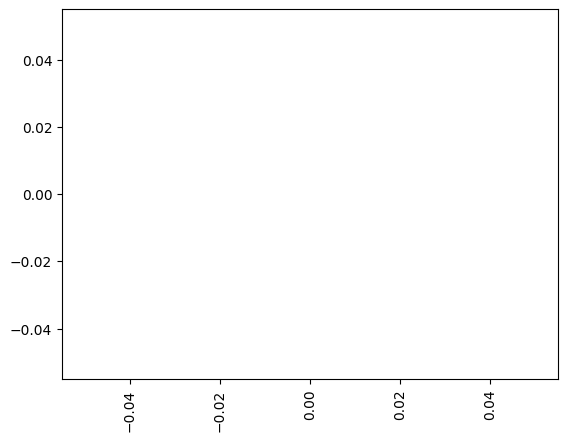

In [20]:
ranking_negados_dia.plot(kind="bar")

plt.title(f"Tentativas Negadas em {dia_especifico}")
plt.xlabel("Colaborador")
plt.ylabel("Quantidade")

plt.tight_layout()
plt.show()